In [1]:
## Business Problem: 
# "Based on county-level labor trends, which geographic markets show signs of a breaking point in the hospital sector (rising costs + shrinking workforce)...
# ...that suggests imminent facility closures or service reductions?"

# Conclusion: From year 2020 to 2025, Alameda County faced decrease of 8% in employment levels, and 29.9% increase in average weekly wage growth, showing signs of breaking point in the hospital sector...
# ...(rising costs + shrinking workforce).

In [2]:
## data preparation

## importing the actual dollar amount for staff compensation

import requests
import pandas as pd
import os
from dotenv import load_dotenv
load_dotenv()
# --- CONFIGURATION ---
# 1. The API Endpoint
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

# 2. Your Registration Key (REPLACE THIS STRING)
api_key = os.getenv("bls_api_key")
if api_key is None:
    raise ValueError("BLS_API_KEY environment variable not set. Please set it in your .env file.")
# 3. The Exact Series IDs for Hospital Operational Costs
# CMU2016220000000D  = Hospitals, Total Compensation (Wages per hour)

series_ids = [
    
    "CMU2016220000000D"
]

# --- THE REQUEST ---
payload = {
    "seriesid": series_ids,
    "startyear": "2020",
    "endyear": "2026",
    "calculations": True,  # Automatically gives you Year-Over-Year % change
    "annualaverage": True, # Smooths data to yearly averages
    "registrationkey": api_key
}

headers = {"Content-Type": "application/json"}

# Send the request
response = requests.post(url, json=payload, headers=headers)
data = response.json()

# --- ERROR CHECKING ---
if data['status'] != 'REQUEST_SUCCEEDED':
    raise Exception(f"API Error: {data['message']}")

# --- PARSE DATA INTO A CLEAN TABLE ---
clean_rows = []

for series in data['Results']['series']:
    sid = series['seriesID']
    for record in series['data']:
        # Extract percent change safely
        pct_change = None
        if 'calculations' in record and 'pct_change' in record['calculations']:
            pct_change = record['calculations']['pct_change']
            
        clean_rows.append({
            "Series_ID": sid,
            "Year": record['year'],
            "Period": record['periodName'],
            "Value": float(record['value']),
            "YoY_Percent_Change": float(pct_change) if pct_change else None
        })

# Create DataFrame
df_dollar = pd.DataFrame(clean_rows)
df_dollar['Year'] = df_dollar['Year'].astype(int)

# Display the result
print("Data Loaded Successfully!")
print(df_dollar.head(30))
df_dollar.to_csv("hospital_labor_costs_dollars.csv", index=False)   
  

Data Loaded Successfully!
            Series_ID  Year       Period  Value YoY_Percent_Change
0   CMU2016220000000D  2026  1st Quarter  66.22               None
1   CMU2016220000000D  2025  4th Quarter  65.65               None
2   CMU2016220000000D  2025  3rd Quarter  71.36               None
3   CMU2016220000000D  2025  2nd Quarter  70.92               None
4   CMU2016220000000D  2025  1st Quarter  70.10               None
5   CMU2016220000000D  2024  4th Quarter  69.77               None
6   CMU2016220000000D  2024  3rd Quarter  68.21               None
7   CMU2016220000000D  2024  2nd Quarter  67.64               None
8   CMU2016220000000D  2024  1st Quarter  67.17               None
9   CMU2016220000000D  2023  4th Quarter  66.05               None
10  CMU2016220000000D  2023  3rd Quarter  61.87               None
11  CMU2016220000000D  2023  2nd Quarter  61.01               None
12  CMU2016220000000D  2023  1st Quarter  60.79               None
13  CMU2016220000000D  2022  4th Qua

In [3]:
df_dollar.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Series_ID           25 non-null     str    
 1   Year                25 non-null     int64  
 2   Period              25 non-null     str    
 3   Value               25 non-null     float64
 4   YoY_Percent_Change  0 non-null      object 
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 1.1+ KB


In [4]:
# importing the employment cost index (eci) to showcase inflation and % change by quater of each year.
import requests
import pandas as pd

url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

api_key = os.getenv("bls_api_key")
if api_key is None:
    raise ValueError("BLS_API_KEY environment variable not set. Please set it in your .env file.")

series_ids = [
    "CIU2016220000000I"
]

payload = {
    "seriesid": series_ids,
    "startyear": "2020",
    "endyear": "2026",
    "calculations": True,  # Automatically gives you Year-Over-Year % change
    "annualaverage": True, # Smooths data to yearly averages
    "registrationkey": api_key
}

headers = {"Content-Type": "application/json"}

response = requests.post(url, json=payload, headers=headers)
data = response.json()

if data['status'] != 'REQUEST_SUCCEEDED':
    raise Exception(f"API Error: {data['message']}")

clean_rows = []

for series in data['Results']['series']:
    sid = series['seriesID']
    for record in series['data']:
        # Extract percent change safely
        pct_change = None
        if 'calculations' in record and 'pct_change' in record['calculations']:
            pct_change = record['calculations']['pct_change']
            
        clean_rows.append({
            "Series_ID": sid,
            "Year": record['year'],
            "Period": record['periodName'],
            "Value": float(record['value']),
            "YoY_Percent_Change": float(pct_change) if pct_change else None
        })

df_index = pd.DataFrame(clean_rows)

# Display the result
print("Data Loaded Successfully!")
print(df_index.head(30))

# Optional: Save to CSV for your project
df_index.to_csv("hospital_labor_costs_index.csv", index=False)   

Data Loaded Successfully!
            Series_ID  Year       Period    Value YoY_Percent_Change
0   CIU2016220000000I  2026  1st Quarter  176.959               None
1   CIU2016220000000I  2025  4th Quarter  175.455               None
2   CIU2016220000000I  2025  3rd Quarter  174.071               None
3   CIU2016220000000I  2025  2nd Quarter  173.279               None
4   CIU2016220000000I  2025  1st Quarter  171.900               None
5   CIU2016220000000I  2024  4th Quarter  169.400               None
6   CIU2016220000000I  2024  3rd Quarter  168.000               None
7   CIU2016220000000I  2024  2nd Quarter  166.500               None
8   CIU2016220000000I  2024  1st Quarter  165.200               None
9   CIU2016220000000I  2023  4th Quarter  162.500               None
10  CIU2016220000000I  2023  3rd Quarter  160.900               None
11  CIU2016220000000I  2023  2nd Quarter  159.400               None
12  CIU2016220000000I  2023  1st Quarter  157.800               None
13  CIU2

In [5]:
# automated download script, manual download would have been a ruckus

import requests
import time
import os

counties = {
    "06037": "Los_Angeles",
    "06073": "San_Diego",
    "06085": "Santa_Clara",
    "06059": "Orange",
    "06001": "Alameda",
    "06065": "Riverside",
    "06067": "Sacramento",
    "06071": "San_Bernardino",
    "06019": "Fresno",
    "06013": "Contra_Costa"
}

years = [2020, 2021, 2022, 2023, 2024, 2025]
quarters = [1,2,3,4]
output_dir = "qcew_data"
os.makedirs(output_dir, exist_ok=True)

for year in years:
    for q in quarters:
        for fips, county_name in counties.items():
            url = f"https://data.bls.gov/cew/data/api/{year}/{q}/area/{fips}.csv"
            filename = os.path.join(output_dir, f"{county_name}_Y{year}_Q{q}.csv")

            # file existence check
            if os.path.exists(filename):
                print(f"File: {filename} already exists, skipping download...")
                continue
    
            print(f"Downloading {url}")
            response = requests.get(url)
    
            if response.status_code == 200:
                with open(filename, "wb" ) as f:
                    f.write(response.content)
                print(f"Saved: {filename}")
            else:
                print(f"Failed: {url} (Status : {response.status_code}")

            time.sleep(.5)
print("Done.")

File: qcew_data\Los_Angeles_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\San_Diego_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Santa_Clara_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Orange_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Alameda_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Riverside_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Sacramento_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\San_Bernardino_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Fresno_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Contra_Costa_Y2020_Q1.csv already exists, skipping download...
File: qcew_data\Los_Angeles_Y2020_Q2.csv already exists, skipping download...
File: qcew_data\San_Diego_Y2020_Q2.csv already exists, skipping download...
File: qcew_data\Santa_Clara_Y2020_Q2.csv already exists, skipping download...
Fil

In [6]:
# merging all the csvs into one final csv for efficient analysis

import pandas as pd
import glob 
import os

folder = 'qcew_data'
all_files = glob.glob(os.path.join(folder, "*.csv"))

df_list = []

for file in all_files:
    base = os.path.basename(file)
    county = base.split("_Y")[0]
    quarter = base.split("_Q")[1].replace(".csv", "")
    year = base.split("_Y")[1].split("_Q")[0]

    df = pd.read_csv(file)
    df['county'] = county.replace("_", " ")
    df["quarter"] = int(quarter)
    df["year"] = int(year)
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df_all = df_all[df_all["industry_code"] == "622"]
print("donee")


donee


In [7]:
df_all.columns

Index(['area_fips', 'own_code', 'industry_code', 'agglvl_code', 'size_code',
       'year', 'qtr', 'disclosure_code', 'qtrly_estabs', 'month1_emplvl',
       'month2_emplvl', 'month3_emplvl', 'total_qtrly_wages',
       'taxable_qtrly_wages', 'qtrly_contributions', 'avg_wkly_wage',
       'lq_disclosure_code', 'lq_qtrly_estabs', 'lq_month1_emplvl',
       'lq_month2_emplvl', 'lq_month3_emplvl', 'lq_total_qtrly_wages',
       'lq_taxable_qtrly_wages', 'lq_qtrly_contributions', 'lq_avg_wkly_wage',
       'oty_disclosure_code', 'oty_qtrly_estabs_chg',
       'oty_qtrly_estabs_pct_chg', 'oty_month1_emplvl_chg',
       'oty_month1_emplvl_pct_chg', 'oty_month2_emplvl_chg',
       'oty_month2_emplvl_pct_chg', 'oty_month3_emplvl_chg',
       'oty_month3_emplvl_pct_chg', 'oty_total_qtrly_wages_chg',
       'oty_total_qtrly_wages_pct_chg', 'oty_taxable_qtrly_wages_chg',
       'oty_taxable_qtrly_wages_pct_chg', 'oty_qtrly_contributions_chg',
       'oty_qtrly_contributions_pct_chg', 'oty_avg_wkl

In [8]:
# correcting column order for county column
cols = ['county'] + [col for col in df_all.columns if col != 'county']
df_all = df_all[cols]

# dropping unecessary columns
df_all = df_all.drop(columns=['quarter',
    'size_code',
    'disclosure_code',
    'lq_disclosure_code',
    'oty_disclosure_code',
    'industry_code',
    'agglvl_code',])

# creating ownership_map from own_code
ownership_map = {
    1:"Federal",
    2:"State",
    3:"Local",
    5:"Private"
} 
# applying mapping function for ownership_map
df_all['ownership_type'] = df_all['own_code'].map(ownership_map)

# correcting order of the ownership_type column
cols = ['county','ownership_type'] + [col for col in df_all.columns if col not in ['county', 'ownership_type']]

# finalising the columns
df_all = df_all[cols]
df_all = df_all[df_all["qtrly_estabs"] != 0]


# removing nulls before saving
remove_null_condition = (df_all["month1_emplvl"] == 0) & (df_all["month2_emplvl"] == 0) & (df_all["month3_emplvl"] == 0)

df_all = df_all[~remove_null_condition]

condition = (df_all['ownership_type'] == 'Federal') & (df_all['avg_wkly_wage'] == 0)

df_all.loc[condition, "avg_wkly_wage"] = 1104
df_all.loc[condition, 'total_qtrly_wages'] = 148313 

df_all.head()

,county,ownership_type,area_fips,own_code,year,qtr,qtrly_estabs,month1_emplvl,month2_emplvl,month3_emplvl,total_qtrly_wages,taxable_qtrly_wages,qtrly_contributions,avg_wkly_wage,lq_qtrly_estabs,lq_month1_emplvl,lq_month2_emplvl,lq_month3_emplvl,lq_total_qtrly_wages,lq_taxable_qtrly_wages,lq_qtrly_contributions,lq_avg_wkly_wage,oty_qtrly_estabs_chg,oty_qtrly_estabs_pct_chg,oty_month1_emplvl_chg,oty_month1_emplvl_pct_chg,oty_month2_emplvl_chg,oty_month2_emplvl_pct_chg,oty_month3_emplvl_chg,oty_month3_emplvl_pct_chg,oty_total_qtrly_wages_chg,oty_total_qtrly_wages_pct_chg,oty_taxable_qtrly_wages_chg,oty_taxable_qtrly_wages_pct_chg,oty_qtrly_contributions_chg,oty_qtrly_contributions_pct_chg,oty_avg_wkly_wage_chg,oty_avg_wkly_wage_pct_chg
249,Alameda,Local,6001,3,2020,1,13,6847,6863,6862,172664992,0,0,1937,1.48,1.85,1.84,1.85,2.13,0.00,0.00,1.15,0,0.0,124,1.8,97,1.4,61,0.9,2091742,1.2,0,0.0,0,0.0,-3,-0.2
2003,Alameda,Private,6001,5,2020,1,34,15583,15636,15704,400287663,9456149,248011,1969,0.49,0.56,0.56,0.57,0.65,0.26,0.30,1.15,-3,-8.1,-68,-0.4,-3,0.0,-62,-0.4,8273666,2.1,335945,3.7,-48747,-16.4,47,2.4
2492,Alameda,Local,6001,3,2020,2,13,6715,6742,6800,174689116,0,0,1990,1.46,1.89,1.91,1.93,2.20,0.00,0.00,1.15,0,0.0,-75,-1.1,-93,-1.4,-64,-0.9,-3151269,-1.8,0,0.0,0,0.0,-13,-0.6
4246,Alameda,Private,6001,5,2020,2,34,15286,15267,15359,387231758,1027616,28072,1946,0.48,0.58,0.59,0.59,0.64,0.25,0.32,1.09,-2,-5.6,-331,-2.1,-486,-3.1,-408,-2.6,-19337670,-4.8,-283406,-21.6,-16104,-36.5,-44,-2.2
4735,Alameda,Local,6001,3,2020,3,13,6831,6838,6890,172895873,0,0,1941,1.46,1.94,1.94,1.96,2.05,0.00,0.00,1.05,0,0.0,-20,-0.3,-57,-0.8,19,0.3,2084210,1.2,0,0.0,0,0.0,29,1.5


In [9]:
# saving the df to csv for future use

df_all.to_csv("merged_counties_data.csv", index=False)
print("donee")

donee


In [10]:
## understanding the df_all on a broader level
# checking for nulls - 0 found

print(df_all.isna().sum())

county                             0
ownership_type                     0
area_fips                          0
own_code                           0
year                               0
qtr                                0
qtrly_estabs                       0
month1_emplvl                      0
month2_emplvl                      0
month3_emplvl                      0
total_qtrly_wages                  0
taxable_qtrly_wages                0
qtrly_contributions                0
avg_wkly_wage                      0
lq_qtrly_estabs                    0
lq_month1_emplvl                   0
lq_month2_emplvl                   0
lq_month3_emplvl                   0
lq_total_qtrly_wages               0
lq_taxable_qtrly_wages             0
lq_qtrly_contributions             0
lq_avg_wkly_wage                   0
oty_qtrly_estabs_chg               0
oty_qtrly_estabs_pct_chg           0
oty_month1_emplvl_chg              0
oty_month1_emplvl_pct_chg          0
oty_month2_emplvl_chg              0
o

In [11]:
# checking for incorrect datatypes - all correct
df_all.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 249 to 543622
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   county                           700 non-null    str    
 1   ownership_type                   700 non-null    str    
 2   area_fips                        700 non-null    int64  
 3   own_code                         700 non-null    int64  
 4   year                             700 non-null    int64  
 5   qtr                              700 non-null    int64  
 6   qtrly_estabs                     700 non-null    int64  
 7   month1_emplvl                    700 non-null    int64  
 8   month2_emplvl                    700 non-null    int64  
 9   month3_emplvl                    700 non-null    int64  
 10  total_qtrly_wages                700 non-null    int64  
 11  taxable_qtrly_wages              700 non-null    int64  
 12  qtrly_contributions              

In [12]:
# counties and their ownership_type's, some counties do no have all four different ownership_type operating hospitals. data is asymmetric but true 
print(df_all[['county','ownership_type']].value_counts())

county          ownership_type
Alameda         Local             24
                Private           24
Contra Costa    Private           24
Fresno          Federal           24
                State             24
                Private           24
Los Angeles     Federal           24
                State             24
                Local             24
                Private           24
Orange          Federal           24
                Private           24
Riverside       Federal           24
                Private           24
Sacramento      Private           24
Santa Clara     Federal           24
                Private           24
San Bernardino  Federal           24
                State             24
                Private           24
San Diego       Federal           24
                Local             24
                Private           24
Contra Costa    Local             16
Fresno          Local             16
Orange          State             16
Riversi

In [13]:
# creating a dictionary for all the months from jan to dec, since they are in quarter months, it is easier to work with them and understand this way.
month_map = {
    (1, 'month1_emplvl'): 1,
    (1, 'month2_emplvl'): 2,
    (1, 'month3_emplvl'): 3,
    (2, 'month1_emplvl'): 4,
    (2, 'month2_emplvl'): 5,
    (2, 'month3_emplvl'): 6,
    (3, 'month1_emplvl'): 7,
    (3, 'month2_emplvl'): 8,
    (3, 'month3_emplvl'): 9,
    (4, 'month1_emplvl'): 10,
    (4, 'month2_emplvl'): 11,
    (4, 'month3_emplvl'): 12
}

# using melt function to reorganise the data accordingly for 'actual' monthly values instead of misleading quarters.
monthly_base = df_all.melt(
    id_vars=['county', 'qtr', 'own_code', 'ownership_type', 'area_fips'],
    value_vars=['month1_emplvl', 'month2_emplvl', 'month3_emplvl'],
    var_name='month_in_qtr',
    value_name='emplvl'
)

# adding 'month' column and applying lamba function
monthly_base['month'] = monthly_base.apply(
    lambda row: month_map[(row['qtr'], row['month_in_qtr'])],
    axis=1
)

# Step 1: Calculate total quarterly employment per group
monthly_base['qtrly_empl'] = monthly_base.groupby(['county', 'qtr', 'own_code'])['emplvl'].transform('sum')

# Step 2: Allocate quarterly wages proportionally to monthly employment
monthly_base['monthly_wages'] = monthly_base.apply(
    lambda row: (df_all[
        (df_all['county'] == row['county']) &
        (df_all['qtr'] == row['qtr']) &
        (df_all['own_code'] == row['own_code'])
    ]['total_qtrly_wages'].values[0] * (row['emplvl'] / row['qtrly_empl'])) 
    if row['qtrly_empl'] != 0 else 0,
    axis=1
)
# (Optional) Drop temporary column to keep the DataFrame clean
monthly_base = monthly_base.drop(columns=['qtrly_empl'])


county_monthly = monthly_base.groupby(['county', 'month'])['emplvl'].sum().reset_index()


print("DONEEEE")

DONEEEE


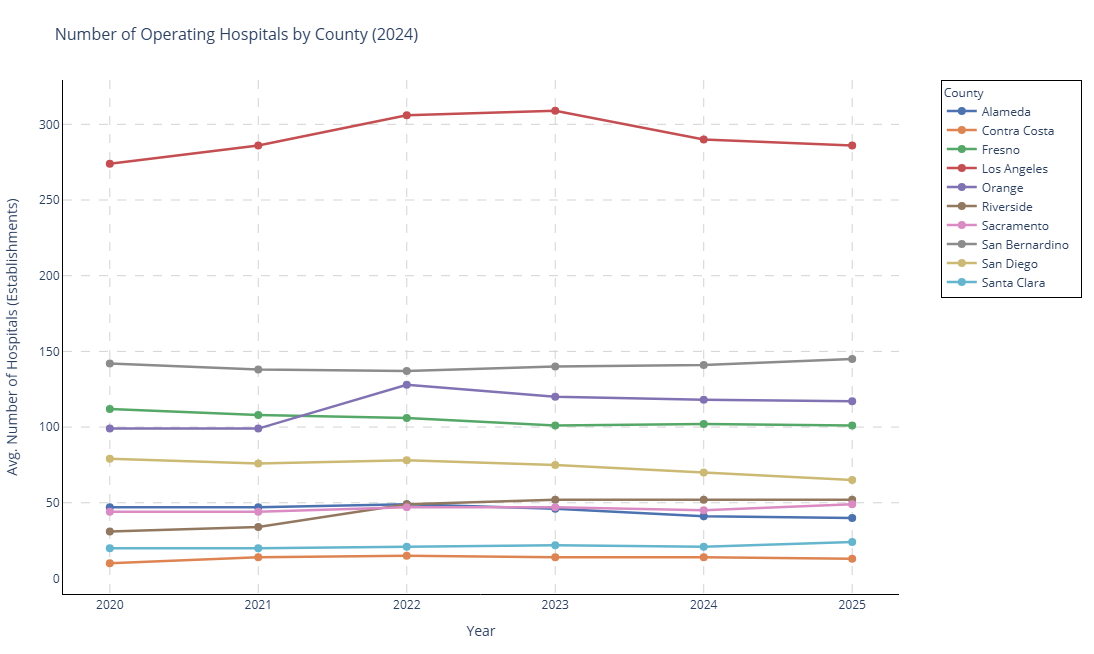

In [14]:
import plotly.express as px
import seaborn as sns
import pandas as pd

# ----------------------------------------------------------------------
# 1. Aggregate to get AVERAGE quarterly count, then ROUND
# ----------------------------------------------------------------------
# Sum ownership types within each county, year, and quarter
quarterly_totals = df_all.groupby(['county', 'year', 'qtr'])['qtrly_estabs'].sum().reset_index()

# Average over quarters for each county-year, then round to whole numbers
yearly_hospitals = quarterly_totals.groupby(['county', 'year'])['qtrly_estabs'].mean().reset_index()
yearly_hospitals['qtrly_estabs'] = yearly_hospitals['qtrly_estabs'].round(0).astype(int)   # <-- ROUNDING HERE

# (If your quarter column is named 'qtr', adjust the groupby keys accordingly)

# ----------------------------------------------------------------------
# 2. Get seaborn colours (exact same palette)
# ----------------------------------------------------------------------
unique_counties = yearly_hospitals['county'].unique()
n_colors = len(unique_counties)
seaborn_palette = sns.color_palette("deep", n_colors=n_colors).as_hex()
color_map = {county: seaborn_palette[i] for i, county in enumerate(unique_counties)}

# ----------------------------------------------------------------------
# 3. Create Plotly figure
# ----------------------------------------------------------------------
fig = px.line(
    yearly_hospitals,
    x='year',
    y='qtrly_estabs',
    color='county',
    markers=True,
    color_discrete_map=color_map,
    labels={'year': 'Year', 'qtrly_estabs': 'Avg. Number of Hospitals (Establishments)'}
)

# Line width and markers to match seaborn defaults
for trace in fig.data:
    trace.line.width = 2.5
    trace.marker.size = 8
    trace.marker.symbol = 'circle'

# ----------------------------------------------------------------------
# 4. Layout – exact same as your original
# ----------------------------------------------------------------------
fig.update_layout(
    title=dict(
        text='Number of Operating Hospitals by County (2024)',
        font=dict(size=16)
    ),
    xaxis=dict(
        title=dict(text='Year', font=dict(size=14)),
        tickvals=[2020, 2021, 2022, 2023, 2024, 2025],
        tickfont=dict(size=12),
        gridcolor='lightgray',
        griddash='dash',
        gridwidth=1,
        showline=True,
        linewidth=1,
        linecolor='black'
    ),
    yaxis=dict(
        title=dict(text='Avg. Number of Hospitals (Establishments)', font=dict(size=14)),
        gridcolor='lightgray',
        griddash='dash',
        gridwidth=1,
        showline=True,
        linewidth=1,
        linecolor='black'
    ),
    legend=dict(
        title=dict(text='County', font=dict(size=12)),
        x=1.05,
        y=1,
        xanchor='left',
        yanchor='top',
        bordercolor='black',
        borderwidth=1
    ),
    width=1120,
    height=640,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=80, b=60)
)

fig.show()

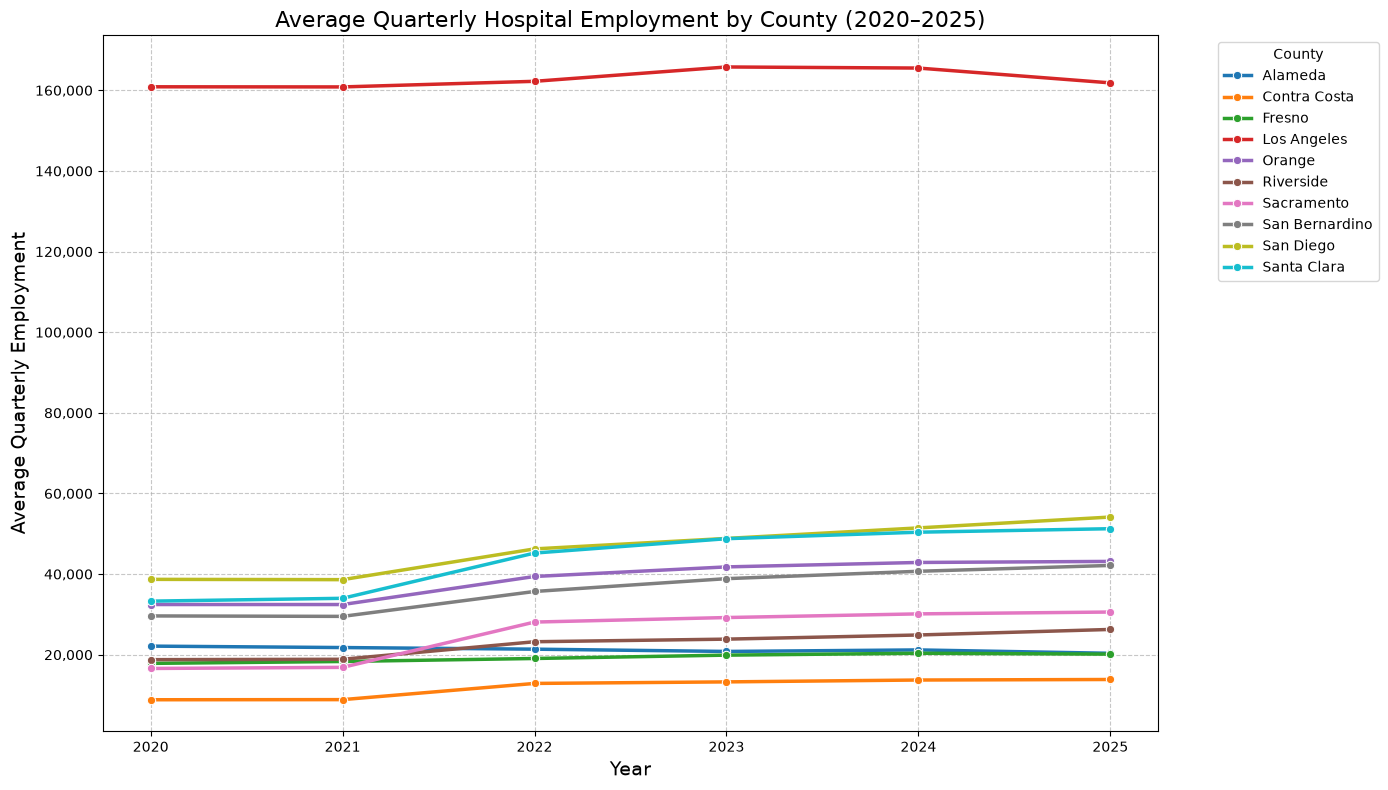

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================================================================
# 1. Compute average monthly employment for each ownership record
# =============================================================================

df = df_all.copy()

df['quarter_avg_empl'] = (
    df[['month1_emplvl', 'month2_emplvl', 'month3_emplvl']]
    .mean(axis=1)
)

# =============================================================================
# 2. Sum ownership types to get county employment each quarter
# =============================================================================

quarterly_avg = (
    df
    .groupby(['county', 'year', 'qtr'], as_index=False)
    .agg(avg_monthly_empl=('quarter_avg_empl', 'sum'))
)

# =============================================================================
# 3. Average the four quarters to get yearly average employment
# =============================================================================

yearly_avg_empl = (
    quarterly_avg
    .groupby(['county', 'year'], as_index=False)
    .agg(avg_monthly_empl=('avg_monthly_empl', 'mean'))
)

# =============================================================================
# 4. Plot
# =============================================================================

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=yearly_avg_empl,
    x='year',
    y='avg_monthly_empl',
    hue='county',
    marker='o',
    linewidth=2.5
)

plt.title('Average Quarterly Hospital Employment by County (2020–2025)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Quarterly Employment', fontsize=14)

plt.legend(
    title='County',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter('{x:,.0f}')

plt.tight_layout()
plt.show()

In [16]:
# Compute the average across years for each county, then round
overall_avg = yearly_hospitals.groupby('county')['qtrly_estabs'].mean().round(0).astype(int)

# Sort from highest to lowest
overall_avg = overall_avg.sort_values(ascending=False)

# Print as a plain text table
print("\nAverage Number of Hospitals per County (all years):")
print("-" * 50)
for county, avg in overall_avg.items():
    print(f"{county:25} {avg:>5}")


Average Number of Hospitals per County (all years):
--------------------------------------------------
Los Angeles                 292
San Bernardino              140
Orange                      114
Fresno                      105
San Diego                    74
Sacramento                   46
Riverside                    45
Alameda                      45
Santa Clara                  21
Contra Costa                 13


In [17]:
# Assuming yearly_hospitals is already created (with rounded yearly averages)
grand_mean = yearly_hospitals['qtrly_estabs'].mean().round(1)
grand_median = yearly_hospitals['qtrly_estabs'].median()

print("Overall summary across all counties and all years:")
print(f"  • Average (mean) number of hospitals per county: {grand_mean}")
print(f"  • Median (more 'typical') number: {grand_median}")
print(f"  • Total number of county‑year observations: {len(yearly_hospitals)}")

Overall summary across all counties and all years:
  • Average (mean) number of hospitals per county: 89.5
  • Median (more 'typical') number: 58.5
  • Total number of county‑year observations: 60


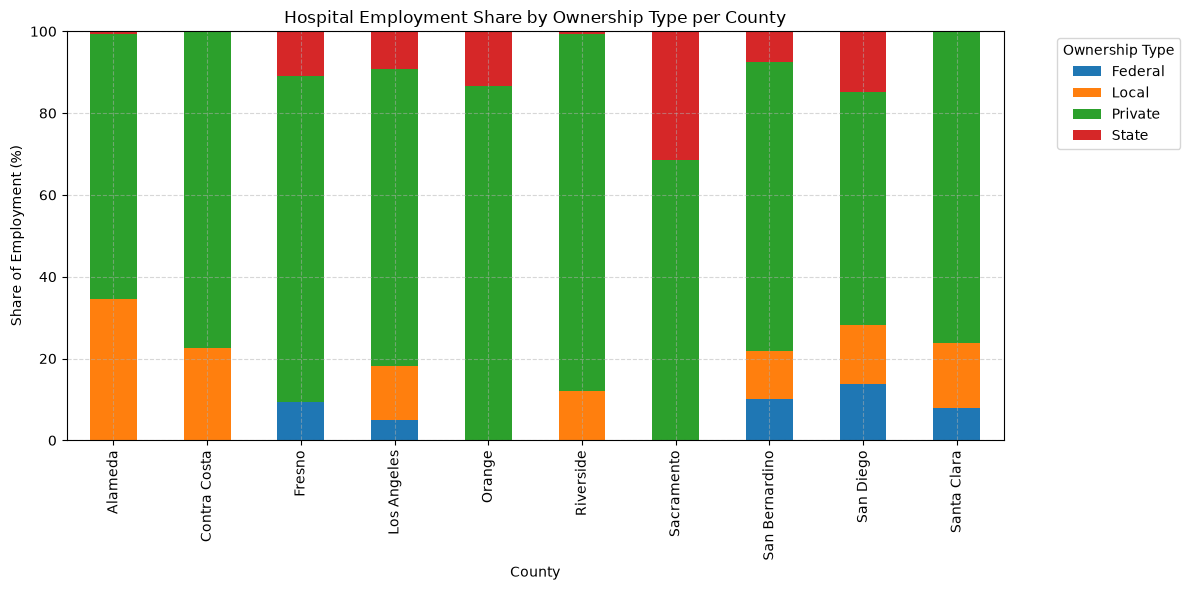

In [18]:
# Employment Share by Ownership Type (Stacked Bar Chart)
ownership_share = monthly_base.groupby(['county', 'ownership_type'])['emplvl'].sum().reset_index()
county_total = ownership_share.groupby('county')['emplvl'].sum().reset_index(name='county_total')
ownership_share = ownership_share.merge(county_total, on='county')
ownership_share['share_pct'] = (ownership_share['emplvl'] / ownership_share['county_total']) * 100

import matplotlib.pyplot as plt
pivot_share = ownership_share.pivot(index='county', columns='ownership_type', values='share_pct').fillna(0)
pivot_share.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Hospital Employment Share by Ownership Type per County')
plt.xlabel('County')
plt.ylabel('Share of Employment (%)')
plt.legend(title='Ownership Type', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

  ownership_type    emplvl  share_pct
0        Federal   1680965   5.452678
1          Local   3753337  12.174993
2        Private  22513331  73.028253
3          State   2880615   9.344076


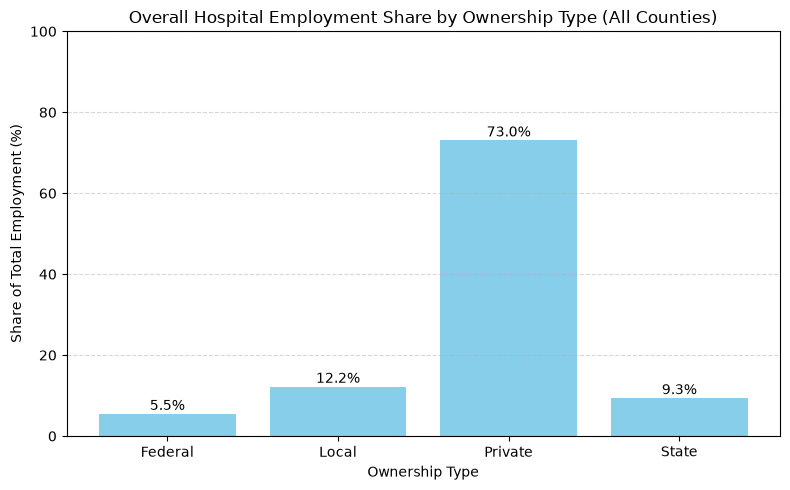

In [19]:
# 1. Aggregate total employment per ownership type across all counties
overall = monthly_base.groupby('ownership_type')['emplvl'].sum().reset_index()

# 2. Compute total employment across all types
total_empl = overall['emplvl'].sum()

# 3. Calculate percentage share
overall['share_pct'] = (overall['emplvl'] / total_empl) * 100

# 4. Display or plot
print(overall)

# Example: simple bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(overall['ownership_type'], overall['share_pct'], color='skyblue')
plt.title('Overall Hospital Employment Share by Ownership Type (All Counties)')
plt.xlabel('Ownership Type')
plt.ylabel('Share of Total Employment (%)')
plt.ylim(0, 100)
for i, v in enumerate(overall['share_pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

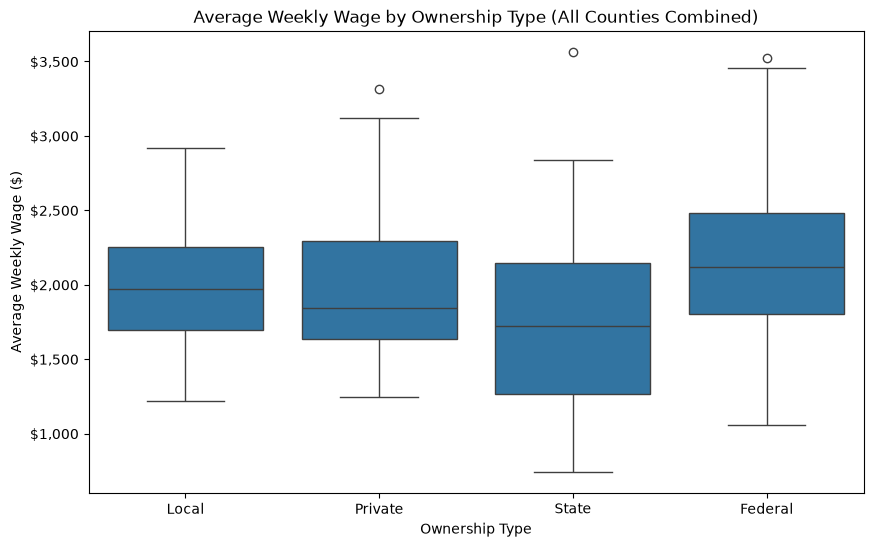

In [20]:
#  Wage by Ownership Type (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all, x='ownership_type', y='avg_wkly_wage')
plt.title('Average Weekly Wage by Ownership Type (All Counties Combined)')
plt.xlabel('Ownership Type')
plt.ylabel('Average Weekly Wage ($)')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.show()

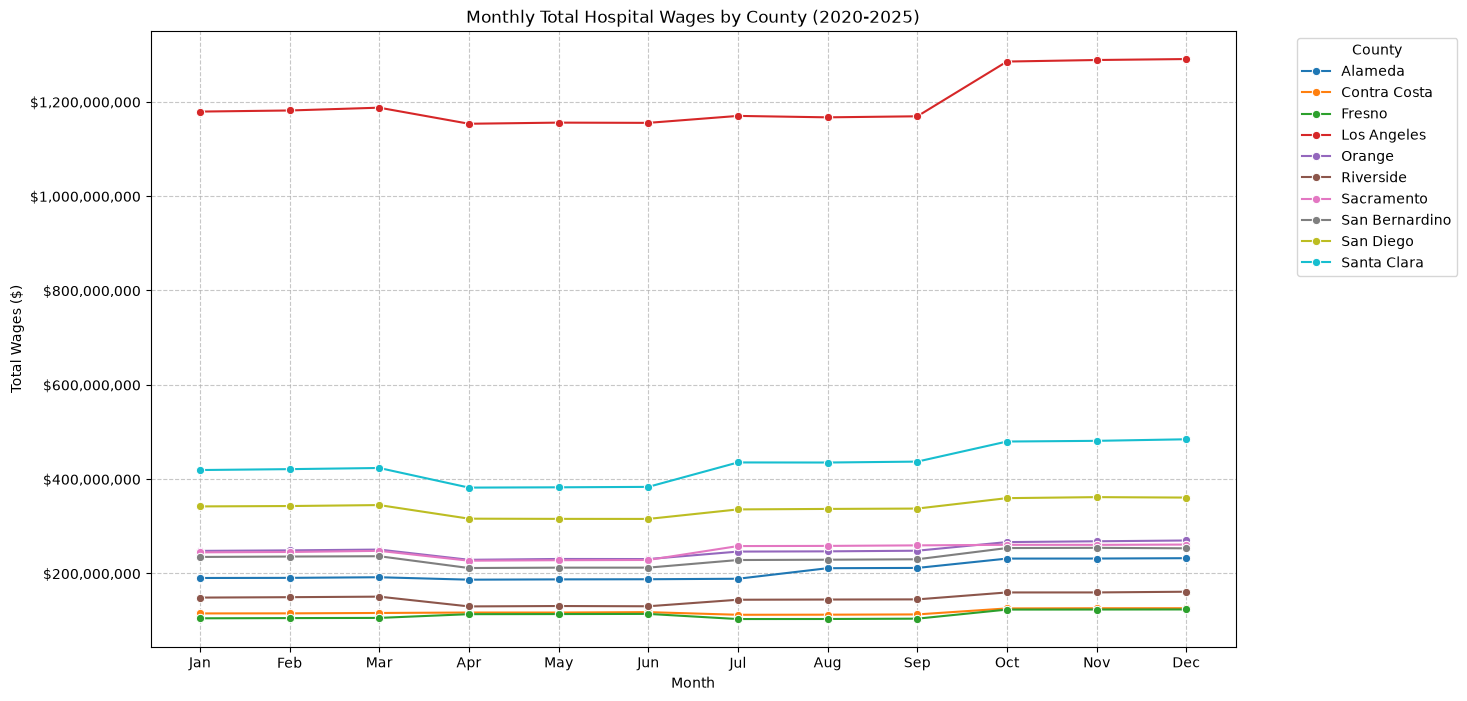

In [21]:
# Monthly Total Hospital Wages by County



county_monthly_wages = monthly_base.groupby(['county', 'month'])['monthly_wages'].sum().reset_index()

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(14, 8))
sns.lineplot(data=county_monthly_wages, x='month', y='monthly_wages', hue='county', marker='o')
plt.title('Monthly Total Hospital Wages by County (2020-2025)')
plt.xlabel('Month')
plt.ylabel('Total Wages ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.show()

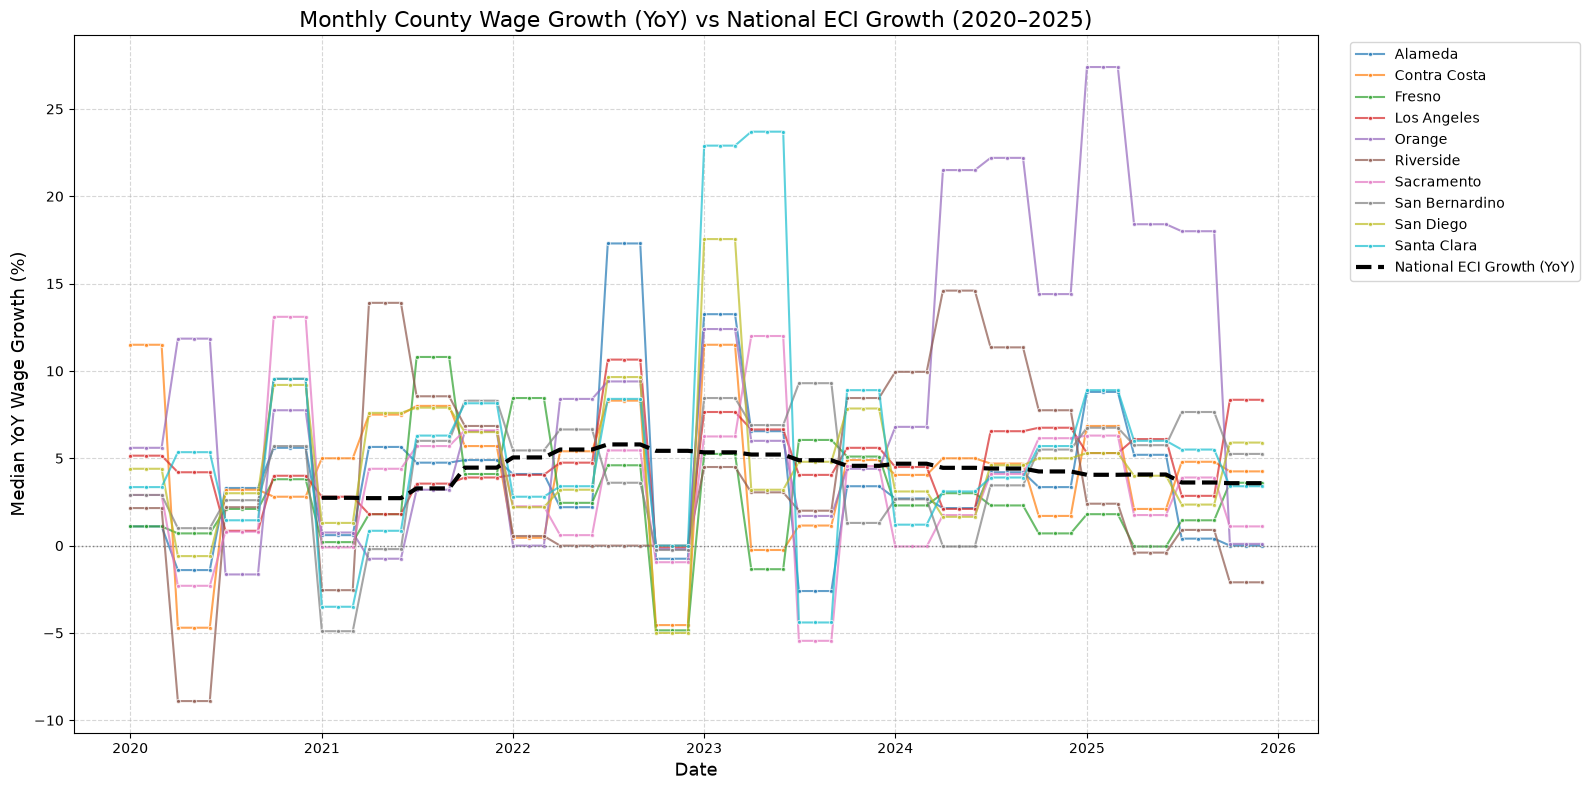

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. Prepare National ECI Data
# =============================================================================

quarter_map = {
    '1st Quarter': 1,
    '2nd Quarter': 2,
    '3rd Quarter': 3,
    '4th Quarter': 4
}

df_index['Year'] = df_index['Year'].astype(int)
df_index['qtr'] = df_index['Period'].map(quarter_map)

# Calculate YoY growth ourselves
df_index = df_index.sort_values(['qtr', 'Year'])

df_index['national_wage_growth'] = (
    df_index.groupby('qtr')['Value']
            .pct_change() * 100
)

national_growth = (
    df_index[['Year', 'qtr', 'national_wage_growth']]
    .rename(columns={'Year': 'year'})
)

# =============================================================================
# 2. County YoY Wage Growth
# =============================================================================

county_growth = (
    df_all
    .groupby(['county', 'year', 'qtr'], as_index=False)
    .agg(county_wage_growth=('oty_avg_wkly_wage_pct_chg', 'median'))
)

county_growth['year'] = county_growth['year'].astype(int)
county_growth['qtr'] = county_growth['qtr'].astype(int)

national_growth['year'] = national_growth['year'].astype(int)
national_growth['qtr'] = national_growth['qtr'].astype(int)

# =============================================================================
# 3. Merge
# =============================================================================

merged = county_growth.merge(
    national_growth,
    on=['year', 'qtr'],
    how='left'
)

# =============================================================================
# 4. Expand quarters into months
# =============================================================================

qtr_to_months = {
    1: [1, 2, 3],
    2: [4, 5, 6],
    3: [7, 8, 9],
    4: [10, 11, 12]
}

rows = []

for _, row in merged.iterrows():
    for month in qtr_to_months[row['qtr']]:
        rows.append({
            'county': row['county'],
            'year': row['year'],
            'month': month,
            'county_wage_growth': row['county_wage_growth'],
            'national_wage_growth': row['national_wage_growth']
        })

monthly_df = pd.DataFrame(rows)

monthly_df['date'] = pd.to_datetime(
    monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str),
    format='%Y-%m'
)

# =============================================================================
# 5. Plot
# =============================================================================

plt.figure(figsize=(16,8))

sns.lineplot(
    data=monthly_df,
    x='date',
    y='county_wage_growth',
    hue='county',
    marker='o',
    markersize=3,
    linewidth=1.5,
    alpha=0.7,
    palette='tab10'
)

sns.lineplot(
    data=monthly_df[['date','national_wage_growth']].drop_duplicates(),
    x='date',
    y='national_wage_growth',
    color='black',
    linestyle='--',
    linewidth=3,
    label='National ECI Growth (YoY)'
)

plt.axhline(0, color='gray', linestyle=':', linewidth=1)

plt.title('Monthly County Wage Growth (YoY) vs National ECI Growth (2020–2025)', fontsize=16)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Median YoY Wage Growth (%)', fontsize=13)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

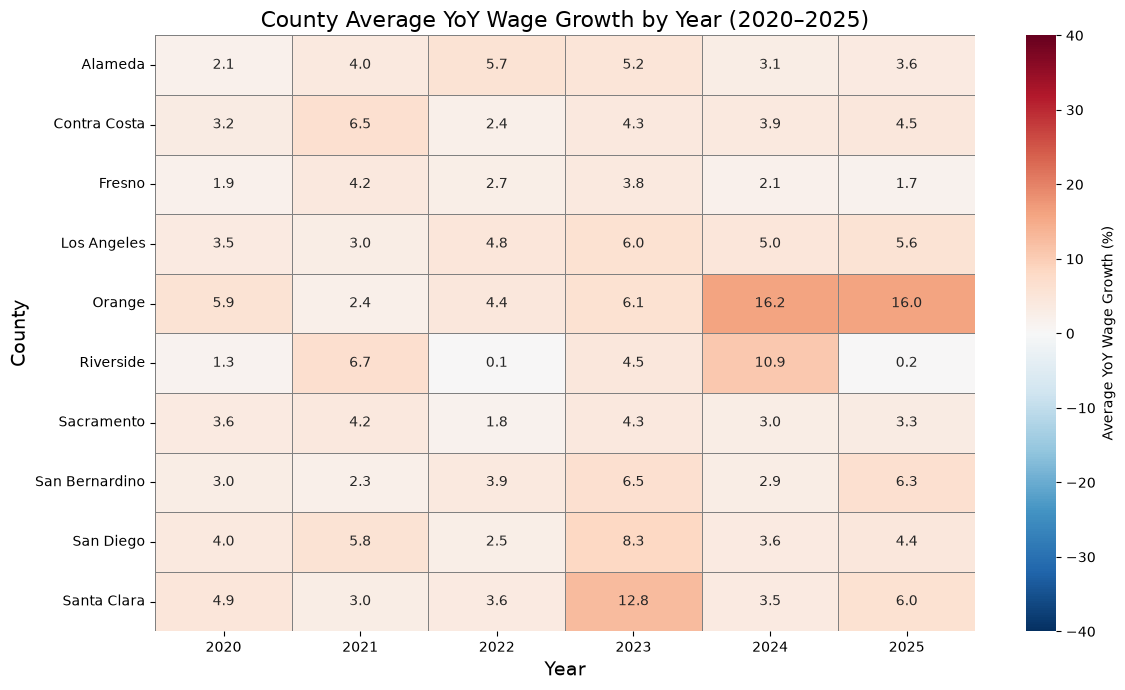

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================================================================
# 1. County average YoY wage growth by year
# =============================================================================

yearly_growth = (
    county_growth
    .groupby(['county', 'year'], as_index=False)
    .agg(county_wage_growth=('county_wage_growth', 'mean'))
)

# =============================================================================
# 2. Pivot for heatmap
# =============================================================================

heatmap_data = (
    yearly_growth
    .pivot(index='county', columns='year', values='county_wage_growth')
)

heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

# =============================================================================
# 3. Plot
# =============================================================================

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdBu_r',
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Average YoY Wage Growth (%)'}
)

plt.title('County Average YoY Wage Growth by Year (2020–2025)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('County', fontsize=14)

plt.tight_layout()
plt.show()

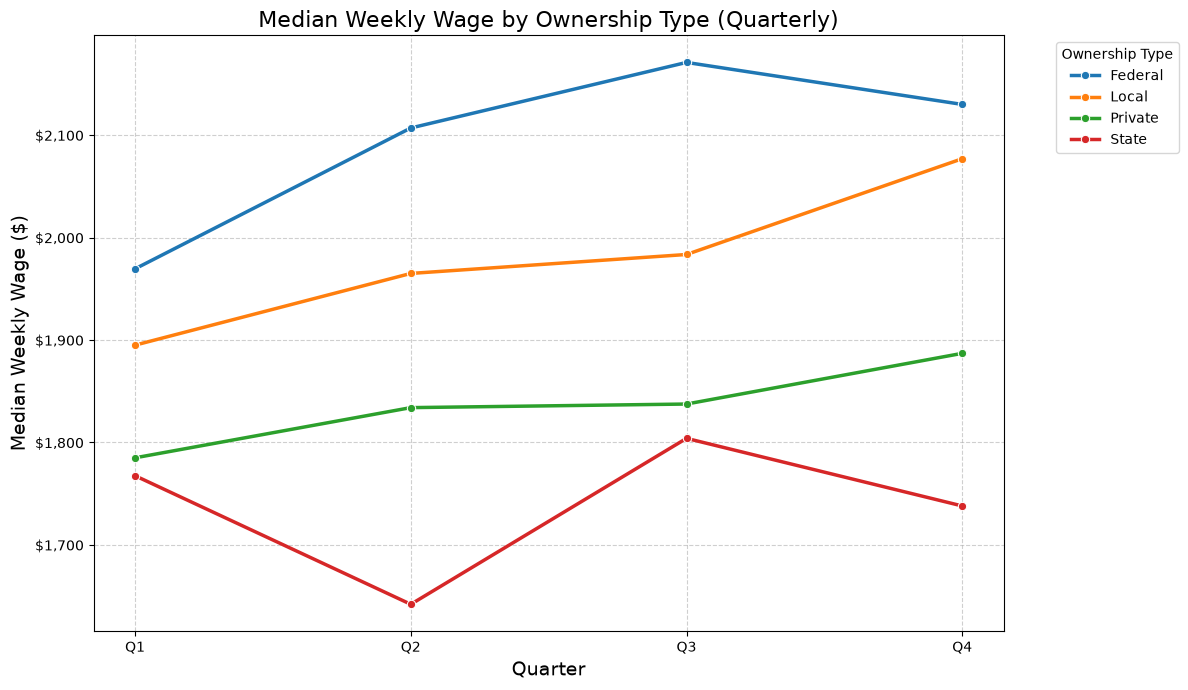

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Compute MEDIAN weekly wage by ownership type and quarter ---
# This gives the "typical" wage per ownership type per quarter, robust to outliers.
quarterly_median = df_all.groupby(['qtr', 'ownership_type']).apply(
    lambda x: pd.Series({'median_wkly_wage': x['avg_wkly_wage'].median()})
).reset_index()

# --- 2. Plot ---
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=quarterly_median,
    x='qtr',
    y='median_wkly_wage',
    hue='ownership_type',
    marker='o',
    linewidth=2.5
)

plt.title('Median Weekly Wage by Ownership Type (Quarterly)', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('Median Weekly Wage ($)', fontsize=14)
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.legend(title='Ownership Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()

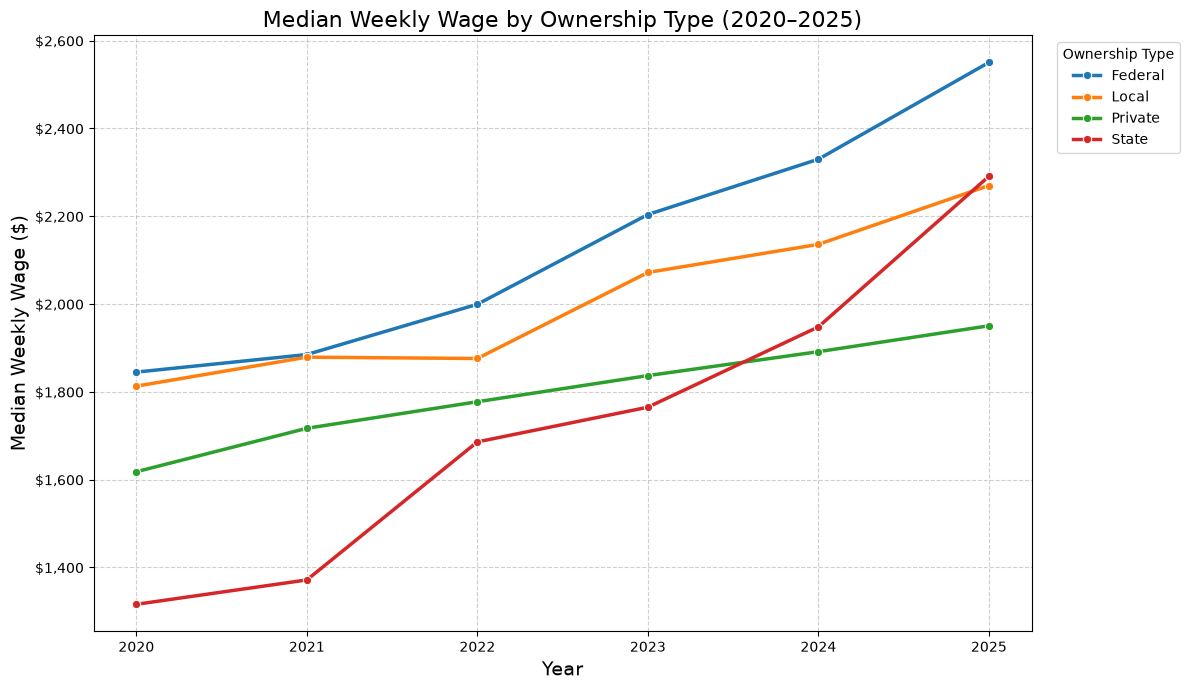

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# =============================================================================
# Median Weekly Wage by Ownership Type (Yearly)
# =============================================================================

# Compute median weekly wage for each ownership type in each year
yearly_ownership = (
    df_all
    .groupby(['year', 'ownership_type'], as_index=False)
    .agg(
        median_wkly_wage=('avg_wkly_wage', 'median')
    )
)

# Ensure year is numeric and sorted
yearly_ownership['year'] = yearly_ownership['year'].astype(int)
yearly_ownership = yearly_ownership.sort_values(['ownership_type', 'year'])

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=yearly_ownership,
    x='year',
    y='median_wkly_wage',
    hue='ownership_type',
    marker='o',
    linewidth=2.5
)

plt.title('Median Weekly Wage by Ownership Type (2020–2025)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Median Weekly Wage ($)', fontsize=14)

plt.xticks(sorted(yearly_ownership['year'].unique()))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    title='Ownership Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

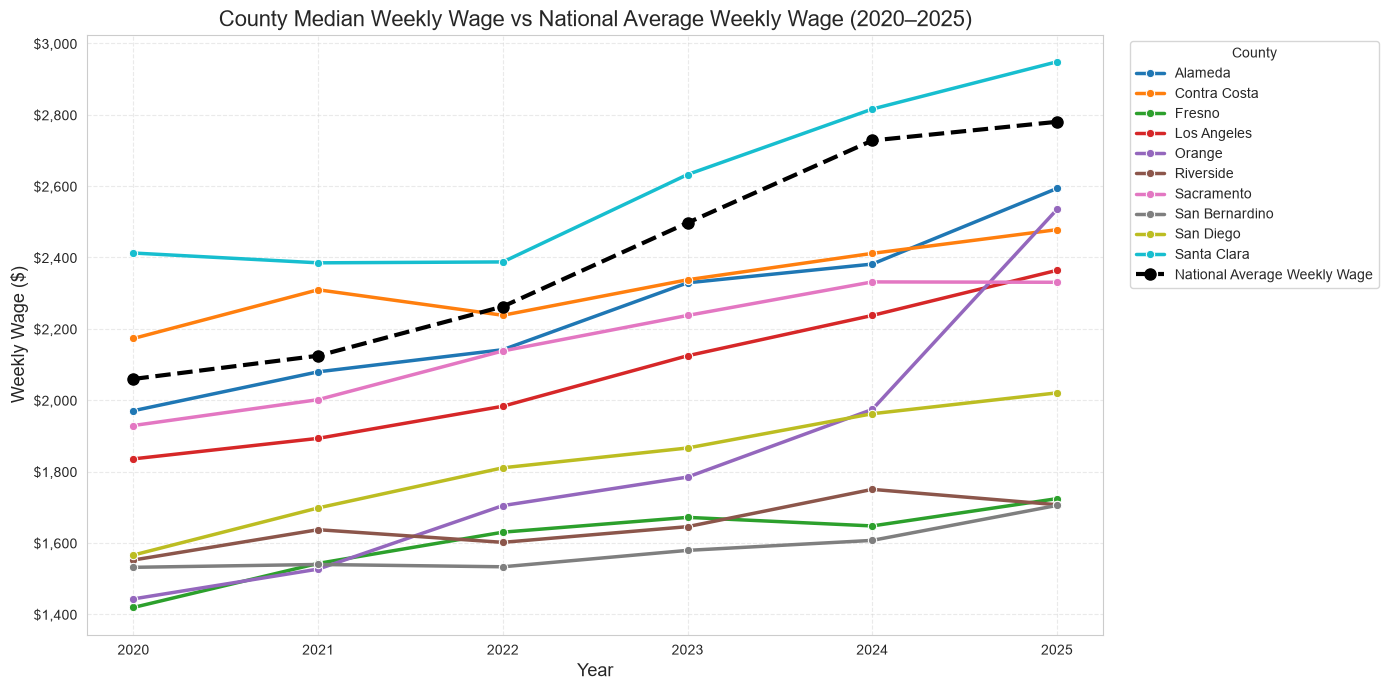

In [26]:
# =============================================================================
# 4. Plot everything on ONE y-axis
# =============================================================================
county_yearly_median = (
    df_all
    .groupby(['year', 'county'], as_index=False)
    .agg(median_wkly_wage=('avg_wkly_wage', 'median'))
)

county_yearly_median['year'] = county_yearly_median['year'].astype(int)
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(14, 7))

# County median weekly wages
sns.lineplot(
    data=county_yearly_median,
    x='year',
    y='median_wkly_wage',
    hue='county',
    marker='o',
    linewidth=2.5,
    palette='tab10',
    ax=ax
)

# National average weekly wage (40 hours/week)
df_dollar['weekly_wage'] = df_dollar['Value'] * 40

national_yearly = (
    df_dollar
    .groupby('Year', as_index=False)
    .agg(national_weekly=('weekly_wage', 'mean'))
)

national_yearly['Year'] = national_yearly['Year'].astype(int)
national_yearly = national_yearly[
    national_yearly['Year'].between(2020, 2025)
]

# National line on SAME axis
ax.plot(
    national_yearly['Year'],
    national_yearly['national_weekly'],
    color='black',
    linestyle='--',
    linewidth=3,
    marker='o',
    markersize=8,
    label='National Average Weekly Wage'
)

# Formatting
ax.set_title(
    'County Median Weekly Wage vs National Average Weekly Wage (2020–2025)',
    fontsize=16
)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Weekly Wage ($)', fontsize=13)
ax.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title='County'
)

plt.tight_layout()
plt.show()

C:\Users\Hima\AppData\Local\Temp\ipykernel_5852\1862938190.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


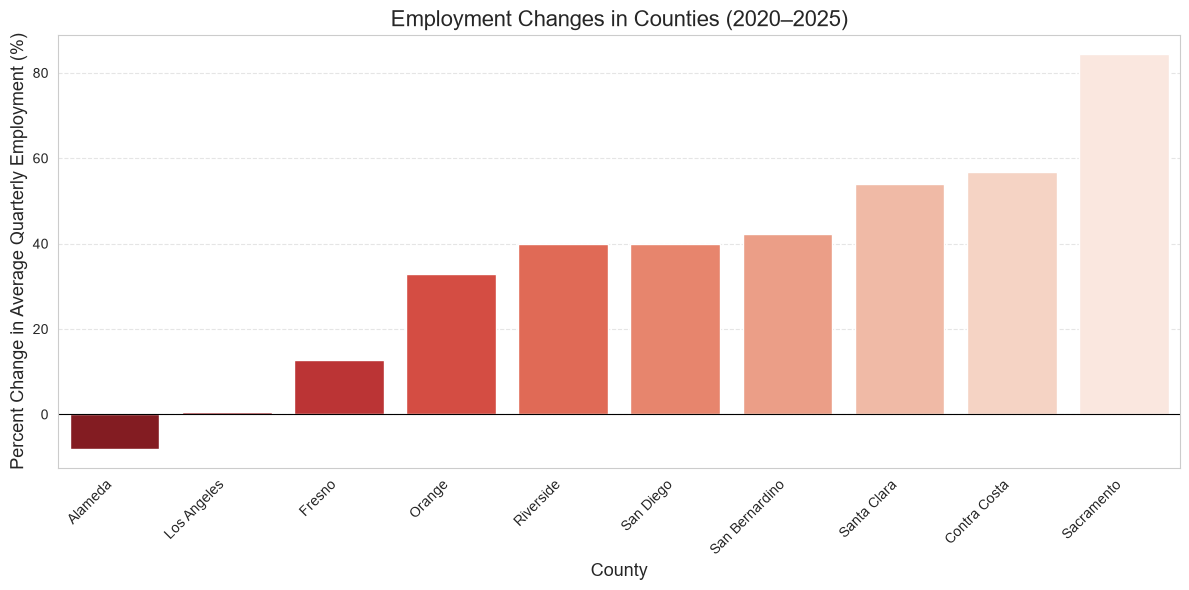

           county      2020      2025  pct_change
0         Alameda   22137.8   20357.7        -8.0
3     Los Angeles  160878.4  161852.3         0.6
2          Fresno   17855.2   20148.0        12.8
4          Orange   32455.3   43149.2        32.9
5       Riverside   18777.4   26273.2        39.9
8       San Diego   38697.8   54155.0        39.9
7  San Bernardino   29625.5   42151.0        42.3
9     Santa Clara   33292.6   51262.4        54.0
1    Contra Costa    8833.8   13857.1        56.9
6      Sacramento   16593.5   30592.9        84.4


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================================================================
# 1. Compute average quarterly employment per county
# =============================================================================

# Average the three months for each record
df_all['quarter_avg_empl'] = (
    df_all['month1_emplvl'] +
    df_all['month2_emplvl'] +
    df_all['month3_emplvl']
) / 3

# Sum across ownership types to get county total for each quarter
quarterly_empl = (
    df_all
    .groupby(['county', 'year', 'qtr'], as_index=False)
    .agg(total_empl=('quarter_avg_empl', 'sum'))
)

# =============================================================================
# 2. Average quarterly employment by year
# =============================================================================

yearly_avg_empl = (
    quarterly_empl
    .groupby(['county', 'year'], as_index=False)
    .agg(avg_empl=('total_empl', 'mean'))
)

# =============================================================================
# 3. Pivot to compare 2020 vs 2025
# =============================================================================

pivot = (
    yearly_avg_empl
    .pivot(index='county', columns='year', values='avg_empl')
    .reset_index()
)

required_years = [2020, 2025]

if not all(year in pivot.columns for year in required_years):
    raise ValueError(
        f"Missing required years. Available years: {[c for c in pivot.columns if isinstance(c, int)]}"
    )

pivot = pivot[['county', 2020, 2025]]
pivot.columns = ['county', '2020', '2025']

# =============================================================================
# 4. Percent change
# =============================================================================

pivot['pct_change'] = (
    (pivot['2025'] - pivot['2020']) /
    pivot['2020']
) * 100

# =============================================================================
# 5. Top 10 largest declines
# =============================================================================

pivot_sorted = pivot.sort_values('pct_change').head(10)

# =============================================================================
# 6. Plot
# =============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=pivot_sorted,
    x='county',
    y='pct_change',
    palette='Reds_r'
)

plt.axhline(0, color='black', linewidth=0.8)

plt.title('Employment Changes in Counties (2020–2025)', fontsize=16)
plt.xlabel('County', fontsize=13)
plt.ylabel('Percent Change in Average Quarterly Employment (%)', fontsize=13)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# 7. Results table
# =============================================================================
pivot_sorted.to_csv('county_employment_change_since_2020.csv')
print(
    pivot_sorted[['county', '2020', '2025', 'pct_change']].round(1)
)

In [28]:
import pandas as pd

# =============================================================================
# 1. Group by county, year, qtr and compute median wage across ownership types
# =============================================================================
# Replace 'avg_wkly_wage' with the actual column name in your data
quarterly_median_wage = (
    df_all
    .groupby(['county', 'year', 'qtr'], as_index=False)
    .agg(median_wage=('avg_wkly_wage', 'median'))   # median across ownerships per quarter
)

# =============================================================================
# 2. Average those quarterly medians across the four quarters to get yearly value
# =============================================================================
yearly_avg_wage = (
    quarterly_median_wage
    .groupby(['county', 'year'], as_index=False)
    .agg(avg_wage=('median_wage', 'mean'))   # mean over quarters (gives yearly average)
)

# =============================================================================
# 3. Pivot to compare 2020 vs 2025
# =============================================================================
pivot = (
    yearly_avg_wage
    .pivot(index='county', columns='year', values='avg_wage')
    .reset_index()
)

required_years = [2020, 2025]
if not all(year in pivot.columns for year in required_years):
    raise ValueError(
        f"Missing required years. Available years: {[c for c in pivot.columns if isinstance(c, int)]}"
    )

pivot = pivot[['county', 2020, 2025]]
pivot.columns = ['county', '2020', '2025']

# =============================================================================
# 4. Percent change
# =============================================================================
pivot['pct_change'] = (
    (pivot['2025'] - pivot['2020']) /
    pivot['2020']
) * 100

# =============================================================================
# 5. Top 10 largest declines (most negative first)
# =============================================================================
pivot_sorted = pivot.sort_values('pct_change').head(10)
pivot_sorted.to_csv('county_wage_change_since_2020.csv')

# =============================================================================
# 6. Print the results table
# =============================================================================
print(
    pivot_sorted[['county', '2020', '2025', 'pct_change']].round(1)
)

           county    2020    2025  pct_change
5       Riverside  1545.9  1548.8         0.2
7  San Bernardino  1502.5  1681.4        11.9
2          Fresno  1453.5  1676.8        15.4
1    Contra Costa  2173.8  2563.5        17.9
6      Sacramento  1996.0  2374.2        19.0
9     Santa Clara  2359.5  2926.8        24.0
3     Los Angeles  1875.5  2373.1        26.5
0         Alameda  2004.8  2605.1        29.9
8       San Diego  1525.5  2111.1        38.4
4          Orange  1516.4  2519.8        66.2


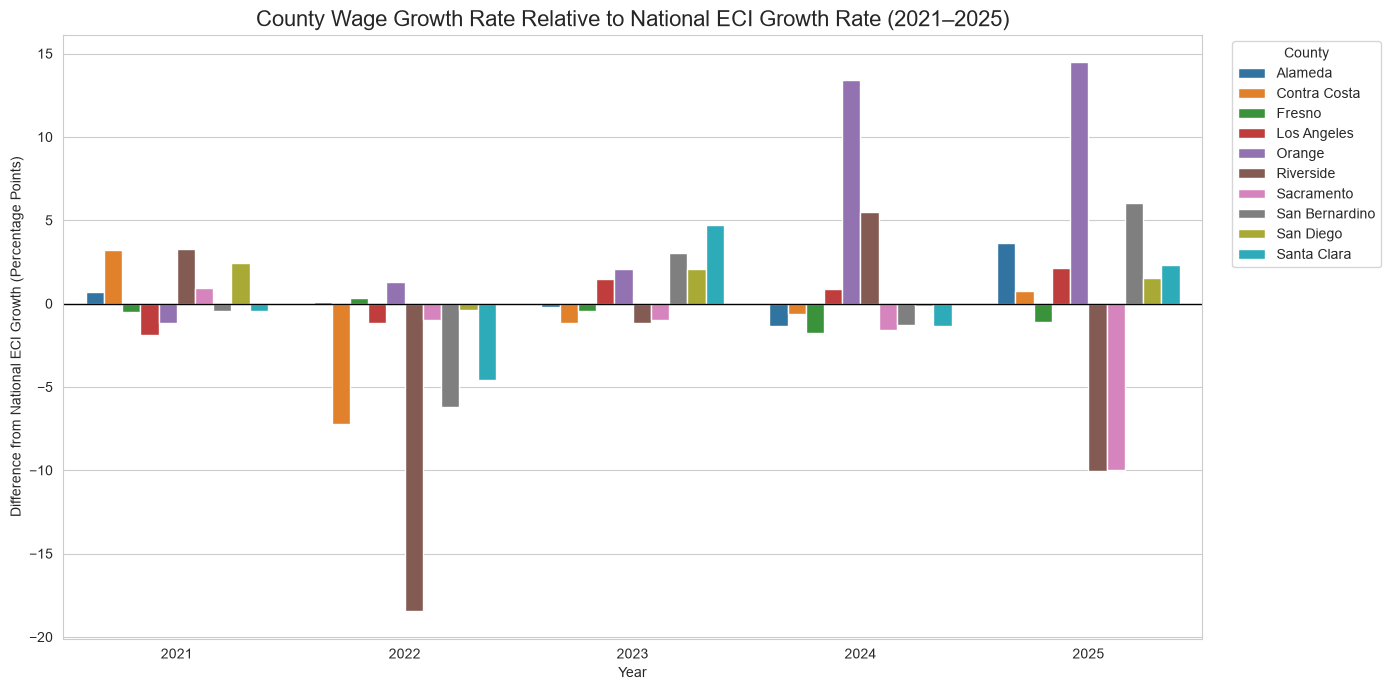

In [29]:
# =============================================================================
# YEAR-OVER-YEAR County Wage Growth vs National ECI Growth (2021–2025)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# National ECI YoY Growth
# ------------------------------------------------------------------

df_index['Year'] = df_index['Year'].astype(int)

national_eci = (
    df_index
    .groupby('Year', as_index=False)
    .agg(avg_eci=('Value', 'mean'))
    .sort_values('Year')
)

national_eci['national_eci_growth'] = (
    national_eci['avg_eci'].pct_change() * 100
)

# ------------------------------------------------------------------
# County Yearly Wage Growth
# ------------------------------------------------------------------

county_yearly = (
    df_all
    .groupby(['year', 'county'], as_index=False)
    .agg(avg_weekly_wage=('avg_wkly_wage', 'mean'))
)

county_yearly = county_yearly.sort_values(['county', 'year'])

county_yearly['county_wage_growth'] = (
    county_yearly
    .groupby('county')['avg_weekly_wage']
    .pct_change() * 100
)

# ------------------------------------------------------------------
# Merge National and County Growth
# ------------------------------------------------------------------

benchmark = county_yearly.merge(
    national_eci[['Year', 'national_eci_growth']],
    left_on='year',
    right_on='Year',
    how='left'
)

benchmark['difference'] = (
    benchmark['county_wage_growth'] -
    benchmark['national_eci_growth']
)

benchmark = benchmark.dropna()

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

plt.figure(figsize=(14,7))

sns.barplot(
    data=benchmark,
    x='year',
    y='difference',
    hue='county'
)

plt.axhline(0, color='black', linewidth=1)

plt.title('County Wage Growth Rate Relative to National ECI Growth Rate (2021–2025)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Difference from National ECI Growth (Percentage Points)')
plt.legend(title='County', bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

In [30]:
## what the ABOVE visual tells:
    # Positive = county wage growth > national → cost pressure.
    # Negative = county wage growth < national → potential competitive advantage.
    # 0 = county wage growth is equal to that of national.

In [31]:
## insights

##Operating Hospitals
# Los Angeles has the highest number of operating hospitals (<280),  2x more than San Bernardino (140), which is following it.
# Contra Costa County has the lowest number of operating hospitals (<25)

## Hospital Ownership Type
# Private Hospitals have the largest share of ownership in all counties but has the lowest median weekly wage.
	# This indicates that private hospitals may rely more on low wage staff,  dragging their median weekly wage.
# Federal Hospitals, on the other hand, have the highest median weekly salary despite having the lowest share of ownership.
	# This indicates that they are likely hiring a group of  highly specialised or advanced individuals.
# Furthermore, Upper end salary of the private owned hospitals can range from $2400-$3100 weekly while federal owned can range from $2500-$3400 weekly.
	# This is factually consistent with the trends of federal owned hospitals, indicating a higher ladder for wage growth.

## Employment
# Los Angeles County employs 3-4 times more hospital staff than the second highest county with the most number of hospitals (i.e  San Bernardino)(why?).	
	# Population may play a role here, La has significantly larger crowd than any other counties in this dataset (for refernce, it is 9 million approx). 
# Contra Costa has the lowest number of employees for hospitals.

## Wages
# Despite San Bernardino having 140 hospitals, Santa Clara which has less than 25 hospitals, provides >2x wages.(why?).
	# It proves that number of hospitals is not equal to economic power.
	# This data likely suggests that the a large portion of those 140 establishments are small or low margin facilities.
	# and those 25 establishments in Santa Clara are that of premium niche, likely highly specialized, or serving a wealthy demographic
	# For context, Cost of living in Santa Clara is approximately 82% to 131% more expensive than the US national average.
# In the last quarters, there is an observable increase in wages across multiple counties(why?). 
	# The national average labor cost index for hospitals increases by 1.01% in the 4th quarter, followed by 1st quarter at 0.86%.
	# Arrival of Winter and consequently flu and cold could push up the total compensation, indicating seasonality. 
	# In the 1st and 4thquarter, when Federal and State owned hospitals saw a decrease in average weekly wages, Local and State owned hospitals saw an increase.
	# Regardless, Local hospitals have rising average weekly wages throughout quarters.
# Fresno County consistently showed the lowest average weekly wages.
# Santa Clara consistently showed the highest average weekly wages, even surpassing the national average.

## Growth rate of wages & employment
# Consistently, highest growth rate of wages was observed to be in Orange County in respect to National ECI Growth, reaching upto 14% in 2025.
# Most fluctuating growth rate of wages was observed to be in Riversie County, going as low as 18% in 2022 to as high as 5.5% in 2024.
# Most consistent growth rate of average weekly wages was observed to be in Local hospitals with little to no fluctuations.
# From year 2020 to 2025, Alameda County at faced decrease of 8% in employment levels, and 29.9% increase in average weekly wage growth, showing signs of breaking point in the hospital sector 
	# ....(rising costs + shrinking workforce).
	# This means there is a labor supply shock in Alameda County.
	# This indicates a potential sustainability crisis where rising labor costs could force service cuts or even closures.

# Counties with largest employment increase from year 2020 to 2025:
	#Sacramento County at +84.4% employment increase and 19% average weekly wage increase.

## YoY County Wage Growth to National ECI
# The most cost pressure is on Orange County hospitals, with 4-8% further wage growth than the average annual, and 66% increase in average weekly wages since 2020.
# Riverside County hospitals have the least wage pressure in respect to YoY wage growth at -10% in year 2025.


In [32]:
# aggregated datasets for Power BI

# 1. Main fact table - monthly hospital metrics
monthly_fact = monthly_base.merge(
    county_monthly_wages, 
    on=['county', 'month']
).merge(
    monthly_df[['county', 'month', 'year', 'county_wage_growth']],
    on=['county', 'month']
)

monthly_fact.to_csv('powerbi_hospital_fact.csv', index=False)

# 2. Dimension tables
# County dimension
county_dim = df_all[['county', 'area_fips']].drop_duplicates()
county_dim.to_csv('powerbi_county_dim.csv', index=False)

# Ownership dimension
ownership_dim = df_all[['ownership_type']].drop_duplicates()
ownership_dim.to_csv('powerbi_ownership_dim.csv', index=False)

# 3. Aggregated views for faster dashboards
yearly_summary = df_all.groupby(['year', 'county']).agg({
    'qtrly_estabs': 'sum',
    'avg_wkly_wage': 'mean',
    'month1_emplvl': 'sum'
}).reset_index()

yearly_summary = yearly_summary.sort_values(['county', 'year'])

yearly_summary['hospitals_pct_change'] = yearly_summary.groupby('county')['qtrly_estabs'].pct_change() * 100
yearly_summary['wage_pct_change'] = yearly_summary.groupby('county')['avg_wkly_wage'].pct_change() * 100
yearly_summary['employment_pct_change'] = yearly_summary.groupby('county')['month1_emplvl'].pct_change() * 100

yearly_summary[['hospitals_pct_change', 'wage_pct_change', 'employment_pct_change']] = yearly_summary[
    ['hospitals_pct_change', 'wage_pct_change', 'employment_pct_change']
].round(1)

yearly_summary.to_csv('powerbi_yearly_summary_with_changes.csv', index=False)
print("done")

done
